阶段1：构造模型

在票价确定的前提下，预测各航段的客流量（已完成）。

阶段2：解析过程

根据客流信息分配舱位，以确定总收益。
客舱分为两类：短途类（AB或BC，称为S类）和长途类（AC，称为L类），总容量为C。

根据是否满座进行分类：

若不满座（S+L≤C），则按S、L和C的预测比例分配舱位，以实现收益最大化。
若满座（S+L>C），则需根据销售量变化预测进行取舍，并作如下判断：
若票价AB+BC>AC，则优先将舱位拆分为AB和BC段销售，S的值取min(AB, BC)，其余舱位分配给L。
若票价AB+BC<AC，则优先分配舱位给AC段，剩余舱位分配给AB和BC段。

阶段3：求总收益最大值

以票价为自变量，总收益为因变量，绘制总收益曲线，并求出总收益的最大值。

# 加载资源

In [54]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import json
import os

def load_resources():
    """
    加载所有预测所需的资源（编码器、模型等）
    
    返回:
    dict: 包含所有加载资源的字典
    """
    resources = {}
    
    # 加载城市标签
    with open('../../my/encoder/city_labels_航班频率加权图标签.json', 'r') as file:
        resources['city_labels'] = json.load(file)
    
    # 加载城市嵌入
    with open('../../my/encoder/城市嵌入编码_航班频率加权图.json', 'r') as file:
        resources['city_embeddings'] = json.load(file)
    
    # 加载城市频率编码
    with open('../../my/encoder/city_map_频率编码.json', 'r') as f:
        resources['city_map'] = json.load(f)
    
    # 加载分类特征编码器
    categorical_columns = ['flt_no', 'aircraft']
    resources['encoders'] = {}
    for col in categorical_columns:
        encoder_path = os.path.join('../../my/encoder/', f"{col}_encoder_all.pkl")
        resources['encoders'][col] = joblib.load(encoder_path)
    
    # 加载标准化器
    resources['scaler_x'] = joblib.load('../../my/encoder/standard_scaler_x.pkl')
    resources['scaler_y'] = joblib.load('../../my/encoder/standard_scaler_y.pkl')
    
    # 加载模型
    resources['model'] = xgb.Booster()
    resources['model'].load_model("../../my/model/频率编码/归一化_xgboost_model_1000.json")
    
    # 预处理城市嵌入为DataFrame格式，方便后续使用
    resources['embedding_df'] = pd.DataFrame.from_dict(
        resources['city_embeddings'], 
        orient='index', 
        columns=['embedding_1', 'embedding_2']
    )
    resources['embedding_df'].index.name = 'city'
    
    # 定义特征列表
    resources['features'] = [
        'flt_no', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 
        'a', 'b', 'c', 'year', 'month', 'day', 'weekday', 'hour', 'minute', 
        'from', 'to', 'unit_price', 'competitor_price', 'a_label', 'b_label', 'c_label', 
        'from_label', 'to_label', 'a_embedding_1', 'a_embedding_2', 'b_embedding_1', 
        'b_embedding_2', 'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 
        'from_embedding_2', 'to_embedding_1', 'to_embedding_2'
    ]
    
    return resources

In [7]:
# 使用 map 对 'a', 'b', 'c', 'from', 'to' 列进行标签化，新增对应的标签列
data['a_label'] = data['a'].map(city_labels_loaded)
data['b_label'] = data['b'].map(city_labels_loaded)
data['c_label'] = data['c'].map(city_labels_loaded)
data['from_label'] = data['from'].map(city_labels_loaded)
data['to_label'] = data['to'].map(city_labels_loaded)

NameError: name 'city_labels_loaded' is not defined

In [5]:
import json

# 从 JSON 文件加载 city_map
with open('../../data-hh/my/encoder/city_map_频率编码.json', 'r') as f:
    city_map = json.load(f)

print("city_map 已从 city_map.json 加载")


city_map 已从 city_map.json 加载


In [6]:
city_map

{'vbo2dwBOeps=': 478332,
 '/M8gHzjxpNU=': 450316,
 'gK3uAaRHrOs=': 446006,
 'So/c8CkA/Xs=': 418933,
 '0J4jz5aCatU=': 408305,
 'g1hKMyP1V8I=': 392450,
 'KETr2NAmAHE=': 382560,
 'a2cXIUGpIbw=': 375628,
 'Qe7TEMbQt6o=': 349099,
 'tKjndGSl9NQ=': 344483,
 'ngSgjHYUqxE=': 307911,
 'MeDwT1+vyYg=': 283642,
 'FWD6O2fHsIU=': 266036,
 'AKQNtuL5r6Q=': 258666,
 'AlGb30xUGAU=': 249630,
 'CnmNtb5MOJA=': 245677,
 'xIqe+QQIQXQ=': 238768,
 'wSF4qXvI044=': 238442,
 'Szk6NJM5C9Y=': 235508,
 'XUXDuFGVfBM=': 217443,
 'xRL77yJN1tk=': 202923,
 'N4hmDZN/CJQ=': 197797,
 'KfwFeosCXek=': 186790,
 'Lue5PP9SfQU=': 185902,
 'hwin1ipuzwk=': 179290,
 '1/9nd1jNCE0=': 161005,
 'grkgazDvJmY=': 152428,
 'OJ0BsQ7KlKk=': 137903,
 'yypkiQCX5lk=': 137323,
 '9j4ofoSZvc4=': 135857,
 'zwVGiYamVc0=': 133583,
 'y+pJ91YLvhA=': 131599,
 'DUbxF00Y8a0=': 127843,
 '9obCP1myMDU=': 125146,
 'F6QbezoeygU=': 121163,
 '/qxKZMQeBus=': 110378,
 'Eg2bemFsI9I=': 108124,
 'z+SilYYwbDk=': 107855,
 'l3TRojr1CBg=': 102309,
 'LLOlT32TdpY=': 96937,
 

In [12]:
# 使用 city_map 替换指定列的值
columns_to_replace = ['a', 'b', 'c', 'from', 'to']

# 遍历指定列并直接用 map 映射
for col in columns_to_replace:
    data[col] = data[col].map(city_map)

# 输出结果
print(data)

               flt_no bd_type    cap aircraft  leg_no  duration  pax  \
0        KgJrsp7Jd78=      窄体  132.0      319       1      1.07   25   
1        P9IRwar34h0=      窄体  189.0      321       1      1.38  151   
2        mJitm0UDfM4=      窄体  132.0      319       1      1.57   38   
3        jXr97M1wpn4=      窄体  132.0      319       1      1.58  109   
4        izjfHOxAho4=      窄体  132.0      319       1      1.80  124   
...               ...     ...    ...      ...     ...       ...  ...   
5999220  BzUm4im0EqA=      窄体  152.0      320       1      3.03   99   
5999221  w+GXbx7u3EM=      窄体  152.0      320       1      2.75  127   
5999222  9ceSbo4suds=      窄体  152.0      320       1      3.48   66   
5999223  +Pv2ewi/JZY=      窄体  158.0      320       1      1.42  157   
5999224  WqHQlgk5y8c=      窄体  158.0      320       1      1.68   95   

                a         b   c  year  month  day  weekday  hour  minute  \
0         29448.0    2515.0 NaN  2023     10    1        6 

In [3]:
import joblib
import pandas as pd

# 定义需要编码的分类特征
categorical_columns = ['flt_no', 'bd_type', 'aircraft', 'a', 'b', 'c', 'from', 'to']

# 加载每个编码器并对测试数据进行编码
for col in categorical_columns:
    # 指定编码器保存的路径
    encoder_path = f"../../data-hh/my/encoder/{col}_encoder.pkl"
    
    # 加载编码器
    le = joblib.load(encoder_path)
    
    # 对测试数据进行标签编码
    data[col] = le.transform(data[col])
    
    # 打印提示，告知编码器已应用
    print(f"{col} 已完成标签编码")

# 测试数据现在已准备好用于预测
print(data.head())

flt_no 已完成标签编码
bd_type 已完成标签编码
aircraft 已完成标签编码
a 已完成标签编码
b 已完成标签编码
c 已完成标签编码
from 已完成标签编码
to 已完成标签编码
   flt_no  bd_type    cap  aircraft  legs  leg_no  duration  pax    a    b  \
0    5995        3  132.0         1     1       1      1.70  127   28  142   
1    6535        3  132.0         1     1       1      2.28   60  138   28   
2    2640        3  164.0         2     1       1      1.63  161  211   88   
3    2815        3  164.0         2     1       1      1.55   57   85  220   
4    7627        3  194.0         3     1       1      1.70  191  211  188   

   ...  year  month  day  weekday  hour  minute  second  from   to  \
0  ...  2023      1    1        6    13      25       0    28  142   
1  ...  2023      1    1        6    16      15       0   142   28   
2  ...  2023      1    1        6    17       5       0   218   88   
3  ...  2023      1    1        6    19      55       0    88  219   
4  ...  2023      1    1        6    16      30       0   218  188   

    unit

In [4]:
# 定义模型输入特征列
input_features = ['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 
                  'a', 'b', 'c', 'year', 'month', 'day', 'weekday', 'hour', 'minute', 'second', 
                  'from', 'to', 'unit_price']

# 定义模型预测特征（这里是 'pax'，但在预测时不需要作为输入）
output_feature = 'pax'

# 提取模型输入特征
X_test = data[input_features]

# 使用模型进行预测
predictions = model.predict(X_test)

# 将预测结果添加到测试数据中
data['pax_prediction'] = predictions

# 查看前几行预测结果
print(data[['pax', 'pax_prediction']].head(20))

    pax  pax_prediction
0   127       93.577560
1    60       81.288231
2   161      120.305305
3    57       91.249695
4   191      131.017731
5    29      117.838379
6   152      112.218712
7    45      104.375839
8   124      114.032417
9    31       94.085876
10  182      152.331696
11   60      135.731720
12   56       66.204521
13  113       79.387238
14   26       49.341080
15   23       64.912888
16  101       84.604362
17   26       58.087208
18   88       72.257629
19  127       91.938560


# 预测单行数据的客流量

In [70]:
def predict_pax(row_data, resources=None):
    """
    预测单行数据的客流量
    
    参数:
    row_data: DataFrame或Series，包含单行数据
    resources: dict, 可选，包含预加载的资源。如果为None，将自动加载
    
    返回:
    float: 预测的客流量
    """
    # 如果没有提供资源，则加载
    if resources is None:
        resources = load_resources()
    
    # 确保输入是DataFrame格式
    if isinstance(row_data, pd.Series):
        row_data = pd.DataFrame([row_data])
    
    # 创建数据的副本，避免修改原始数据
    row_data = row_data.copy()
    
    # 添加城市标签
    row_data['a_label'] = row_data['a'].map(resources['city_labels'])
    row_data['b_label'] = row_data['b'].map(resources['city_labels'])
    row_data['c_label'] = row_data['c'].map(resources['city_labels'])
    row_data['from_label'] = row_data['from'].map(resources['city_labels'])
    row_data['to_label'] = row_data['to'].map(resources['city_labels'])
    
    # 添加城市嵌入
    cities = ['a', 'b', 'c', 'from', 'to']
    for city in cities:
        # 使用right_index=True方式合并
        row_data = row_data.merge(resources['embedding_df'], left_on=city, right_index=True, how='left')
        
        # 重命名列以避免冲突
        row_data.rename(columns={
            'embedding_1': f'{city}_embedding_1', 
            'embedding_2': f'{city}_embedding_2'
        }, inplace=True)
    
    # 应用频率编码
    for col in ['a', 'b', 'c', 'from', 'to']:
        row_data[col] = row_data[col].map(resources['city_map'])
    
    # 应用标签编码
    for col in resources['encoders'].keys():
        try:
            row_data[col] = resources['encoders'][col].transform(row_data[col])
        except ValueError:
            # 处理未见过的类别
            print(f"警告: {col}列中存在未见过的类别，将使用默认值0")
            row_data[col] = 0
            
    
    # 特征选择
    print(resources['features'])
    X = row_data[resources['features']]
    pd.set_option('display.max_columns', None)  # 显示所有列
    print(X)
    
    # 标准化特征
    X_scaled = resources['scaler_x'].transform(X)

    X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
    print(X_scaled)
    
    # 预测
    dmatrix = xgb.DMatrix(X_scaled)
    print(dmatrix)
    scaled_predictions = resources['model'].predict(dmatrix)
    
    # 反标准化预测结果
    predictions = resources['scaler_y'].inverse_transform(scaled_predictions.reshape(-1, 1))
    
    return predictions[0][0]

In [60]:
data = pd.read_csv('./pre_2023-2024_with_comp_test.csv', dtype={'flt_no': str})
print(data.info())
# 单行预测示例
test_row = data.iloc[[0]]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282755 entries, 0 to 282754
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   flt_no            282755 non-null  object 
 1   cap               282755 non-null  int64  
 2   aircraft          282755 non-null  object 
 3   legs              282755 non-null  int64  
 4   leg_no            282755 non-null  int64  
 5   duration          282727 non-null  float64
 6   pax               282755 non-null  int64  
 7   a                 282755 non-null  object 
 8   b                 282755 non-null  object 
 9   c                 112308 non-null  object 
 10  unit_price        282755 non-null  float64
 11  competitor_price  282755 non-null  float64
 12  year              282755 non-null  int64  
 13  month             282755 non-null  int64  
 14  day               282755 non-null  int64  
 15  weekday           282755 non-null  int64  
 16  hour              28

In [42]:
test_row
# 简洁版本
print("test_row 的数据类型和值:")
for column, value in test_row.items():
    print(f"{column}: {value} (类型: {type(value).__name__})")

test_row 的数据类型和值:
flt_no: 0    7558
Name: flt_no, dtype: object (类型: Series)
cap: 0    110
Name: cap, dtype: int64 (类型: Series)
aircraft: 0    195
Name: aircraft, dtype: object (类型: Series)
legs: 0    1
Name: legs, dtype: int64 (类型: Series)
leg_no: 0    1
Name: leg_no, dtype: int64 (类型: Series)
duration: 0    1.3
Name: duration, dtype: float64 (类型: Series)
pax: 0    97
Name: pax, dtype: int64 (类型: Series)
a: 0    AAT
Name: a, dtype: object (类型: Series)
b: 0    URC
Name: b, dtype: object (类型: Series)
c: 0    NaN
Name: c, dtype: object (类型: Series)
unit_price: 0    470.474227
Name: unit_price, dtype: float64 (类型: Series)
competitor_price: 0   -68.7985
Name: competitor_price, dtype: float64 (类型: Series)
year: 0    2023
Name: year, dtype: int64 (类型: Series)
month: 0    1
Name: month, dtype: int64 (类型: Series)
day: 0    1
Name: day, dtype: int64 (类型: Series)
weekday: 0    6
Name: weekday, dtype: int64 (类型: Series)
hour: 0    14
Name: hour, dtype: int64 (类型: Series)
minute: 0    35
Name: min

In [71]:
predicted_pax = predict_pax(test_row)

['flt_no', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday', 'hour', 'minute', 'from', 'to', 'unit_price', 'competitor_price', 'a_label', 'b_label', 'c_label', 'from_label', 'to_label', 'a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 'to_embedding_1', 'to_embedding_2']
   flt_no  cap  aircraft  legs  leg_no  duration     a       b   c  year  \
0    2846   94         0     1       1      1.33  1802  119514 NaN  2024   

   month  day  weekday  hour  minute  from      to  unit_price  \
0      7    1        0    12      30  1802  119514  481.555556   

   competitor_price  a_label  b_label  c_label  from_label  to_label  \
0       -119.744444        2        2      NaN           2         2   

   a_embedding_1  a_embedding_2  b_embedding_1  b_embedding_2  c_embedding_1  \
0       1.359785       0.666016       1.191599       1.067956            NaN

In [72]:
predicted_pax

70.36507

## 座位分配

根据三段客流量按照分配策略进行分配

写一个函数
    
    输入为ab,bc,ac的票价和预测客流量和cap
    输出为ab，bc，ac分配的舱位数和总收益

模型的完整输入特征为

'flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2'


加载模型和编码器，包括../../data-hh/my/模型文件/频率编码/归一化_xgboost_model_1000.json模型
包括'flt_no', 'bd_type', 'aircraft'编码器，
加载x和y的标准化器
加载城市频率编码器，城市标签编码器，城市嵌入编码器


### 测试数据

In [136]:
# 测试数据
test_data = {
    'flt_date': '2024-1-1',
    'flt_no': '/O2MVlG1lP0=',
    'bd_type': '窄体',
    'dep_time': '07:00:00',
    'ab_cap': 194.0,  # AB航段容量
    'bc_cap': 194.0,  # BC航段容量
    'ac_cap': np.nan,  # AC航段容量
    'aircraft': '321',
    'ab_duration': 2.38,    # AB航段时长
    'bc_duration': 2.68,    # BC航段时长
    'ac_duration': np.nan,  # AC航段时长
    'a': 'xIqe+QQIQXQ=',
    'b': 'AfKac4FzdXs=',
    'c': 'So/c8CkA/Xs=',
    'ab_price': 982.02,
    'bc_price': 476.36,
    'ac_price': 1441.70
}

2023/1/1	tKjndGSl9NQ=-5t+HPO9Mu/w=	P6p42wyZFEI=	窄体	8:50:00	0	319	3	3	0	11774	7	tKjndGSl9NQ=	KETr2NAmAHE=	5t+HPO9Mu/w=
2023/1/1	KETr2NAmAHE=-5t+HPO9Mu/w=	P6p42wyZFEI=	窄体	12:55:00	132	319	3	2	2.68	70520	56	tKjndGSl9NQ=	KETr2NAmAHE=	5t+HPO9Mu/w=
2023/1/1	tKjndGSl9NQ=-KETr2NAmAHE=	P6p42wyZFEI=	窄体	8:50:00	132	319	3	1	2.38	118377	113	tKjndGSl9NQ=	KETr2NAmAHE=	5t+HPO9Mu/w=
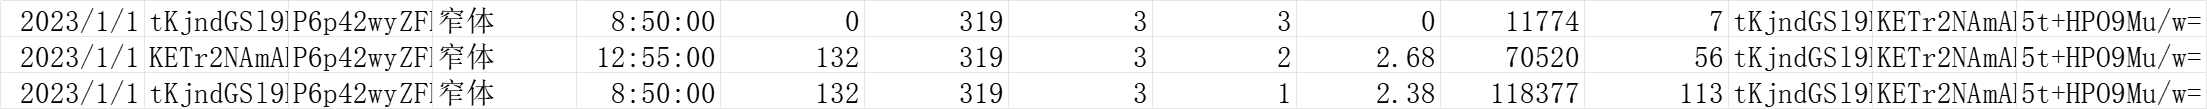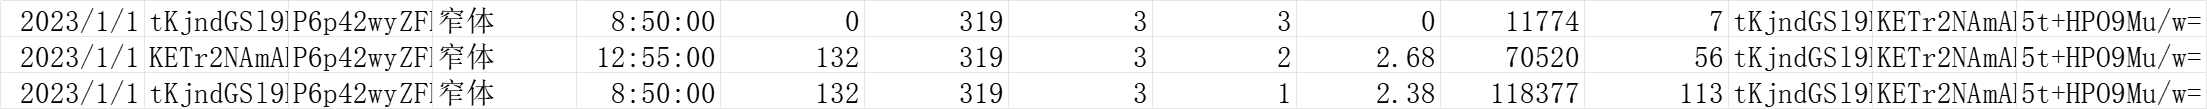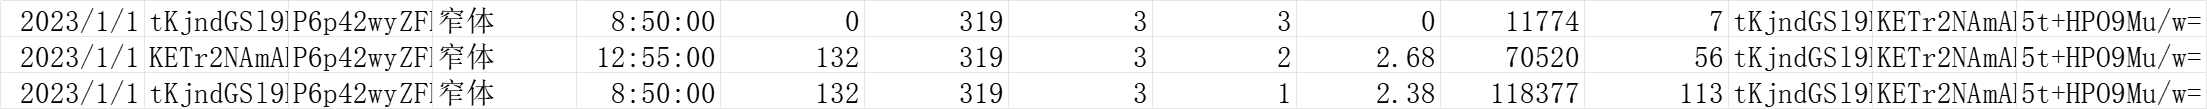

In [167]:
# 测试数据
test_data = {
    'flt_date': '2023-1-1',
    'flt_no': 'P6p42wyZFEI=',  # 从图片中第一行获取
    'bd_type': '窄体',
    'dep_time': '08:50:00',  # 从图片中第一行获取
    'ab_cap': 132.0,  # 从图片中获取
    'bc_cap': 132.0,  # 从图片中获取
    'ac_cap': np.nan,  # 从图片中获取
    'aircraft': '319',  # 从图片中获取
    'ab_duration': 2.38,    # 从图片中第三行leg_no=1的duration获取
    'bc_duration': 2.68,    # 从图片中第二行leg_no=2的duration获取
    'ac_duration': 0.0,     # 从图片中第一行leg_no=3的duration获取
    'a': 'tKjndGSl9NQ=',      # 从图片中航班号的第一部分获取
    'b': 'KETr2NAmAHE=',   # 从图片中航班号的中间部分获取
    'c': '5t+HPO9Mu/w=',      # 从图片中航班号的最后部分获取
    # 'ab_price': 1048,    # 这些价格可以保持不变
    # 'bc_price': 1259,    # 因为图片中没有显示价格信息
    # 'ac_price': 1682
    'ab_price': 1048,    # 这些价格可以保持不变
    'bc_price': 2000,    # 因为图片中没有显示价格信息
    'ac_price': 2000
}



### 加载模型和编码器

In [173]:
def load_model_and_encoders():
    """
    加载所有模型、编码器和标准化器。
    
    返回：
    - model: XGBoost模型
    - label_encoders: 分类特征的标签编码器字典
    - scaler_x: 特征标准化器
    - scaler_y: 目标值标准化器
    - city_map: 城市频率编码映射
    - city_labels: 城市标签编码映射
    - city_embeddings: 城市嵌入编码字典
    """
    import xgboost as xgb
    import joblib
    import json
    import pandas as pd
    
    # 1. 加载XGBoost模型
    model = xgb.XGBRegressor()
    model.load_model("../../data-hh/my/模型文件/频率编码/归一化_xgboost_model_1000.json")
    
    # 2. 加载标签编码器
    categorical_columns = ['flt_no', 'bd_type', 'aircraft']
    label_encoders = {}
    for col in categorical_columns:
        label_encoders[col] = joblib.load(f"../../data-hh/my/encoder/{col}_encoder_all.pkl")
    
    # 3. 加载标准化器
    scaler_x = joblib.load('../../data-hh/my/encoder/standard_scaler_x.pkl')
    scaler_y = joblib.load('../../data-hh/my/encoder/standard_scaler_y.pkl')
    
    # 4. 加载城市频率编码映射
    with open('../../data-hh/my/encoder/city_map_频率编码.json', 'r') as f:
        city_map = json.load(f)
    
    # 5. 加载城市标签编码映射
    with open('../../data-hh/my/encoder/city_labels_航班频率加权图标签.json', 'r') as f:
        city_labels = json.load(f)
    
    # 6. 加载城市嵌入编码（修改了文件路径）
    with open('../../data-hh/my/encoder/城市嵌入编码_航班频率加权图.json', 'r') as f:
        city_embeddings = json.load(f)
    
    print("所有模型和编码器加载完成")
    
    return model, label_encoders, scaler_x, scaler_y, city_map, city_labels, city_embeddings

#### 验证加载正确性

In [141]:
# 加载所有模型和编码器
model, label_encoders, scaler_x, scaler_y, city_map, city_labels, city_embeddings = load_model_and_encoders()

所有模型和编码器加载完成


In [142]:
label_encoders

{'flt_no': LabelEncoder(),
 'bd_type': LabelEncoder(),
 'aircraft': LabelEncoder()}

In [143]:
# 加载所有模型和编码器
model, label_encoders, scaler_x, scaler_y, city_map, city_labels, city_embeddings = load_model_and_encoders()

# 测试数据
test_data = {
    'flt_no': '/O2MVlG1lP0=',
    'bd_type': '窄体',
    'aircraft': '321'
}

# 对每个特征进行编码并打印结果
for feature, value in test_data.items():
    try:
        encoded_value = label_encoders[feature].transform([value])[0]
        print(f"{feature}: {value} -> {encoded_value}")
        
        # 验证反向转换
        decoded_value = label_encoders[feature].inverse_transform([encoded_value])[0]
        print(f"反向转换验证: {encoded_value} -> {decoded_value}")
        print("-" * 50)
    except Exception as e:
        print(f"编码 {feature} 时出错: {str(e)}")

所有模型和编码器加载完成
flt_no: /O2MVlG1lP0= -> 230
反向转换验证: 230 -> /O2MVlG1lP0=
--------------------------------------------------
bd_type: 窄体 -> 3
反向转换验证: 3 -> 窄体
--------------------------------------------------
aircraft: 321 -> 7
反向转换验证: 7 -> 321
--------------------------------------------------


验证结果正确

In [144]:
# 测试城市编码
test_city = 'xIqe+QQIQXQ='

# 1. 验证频率编码映射
try:
    freq_value = city_map[test_city]
    print(f"频率编码映射结果: {test_city} -> {freq_value}")
except Exception as e:
    print(f"频率编码映射出错: {str(e)}")
print("-" * 50)

# 2. 验证标签编码映射
try:
    label_value = city_labels[test_city]
    print(f"标签编码映射结果: {test_city} -> {label_value}")
except Exception as e:
    print(f"标签编码映射出错: {str(e)}")
print("-" * 50)

# 3. 验证嵌入编码映射
try:
    embedding_value = city_embeddings[test_city]
    print(f"嵌入编码映射结果: {test_city} -> {embedding_value}")
except Exception as e:
    print(f"嵌入编码映射出错: {str(e)}")
print("-" * 50)

频率编码映射结果: xIqe+QQIQXQ= -> 238768
--------------------------------------------------
标签编码映射结果: xIqe+QQIQXQ= -> 0
--------------------------------------------------
嵌入编码映射结果: xIqe+QQIQXQ= -> [0.8442193269729614, 0.6705954074859619]
--------------------------------------------------


验证结果正确

In [145]:
import numpy as np

# 测试值
test_y = 128

# 将单个值转换为2D数组（scaler需要2D输入）
test_y_2d = np.array(test_y).reshape(-1, 1)

try:
    # 进行标准化
    scaled_y = scaler_y.transform(test_y_2d)
    print(f"原始值: {test_y}")
    print(f"标准化后的值: {scaled_y[0][0]}")
    
    # 验证反向转换
    inverse_y = scaler_y.inverse_transform(scaled_y)
    print(f"反向转换后的值: {inverse_y[0][0]}")
    
    # 验证精度
    if np.abs(test_y - inverse_y[0][0]) < 1e-10:
        print("\n验证结果: 转换前后的值完全一致")
    else:
        print("\n验证结果: 转换前后的值有差异")
        print(f"差异值: {np.abs(test_y - inverse_y[0][0])}")
        
except Exception as e:
    print(f"标准化过程出错: {str(e)}")

原始值: 128
标准化后的值: 0.3199251946499926
反向转换后的值: 128.0

验证结果: 转换前后的值完全一致


### 数据预处理

In [174]:
def preprocess_data(flt_date, flt_no, bd_type, dep_time, ab_cap, bc_cap, ac_cap, aircraft, 
                   ab_duration, bc_duration, ac_duration, 
                   a, b, c, ab_price, bc_price, ac_price, 
                   model, label_encoders, scaler_x, city_map, city_labels, city_embeddings):
    """
    对输入数据进行预处理
    """
    import pandas as pd
    import numpy as np
    from datetime import datetime
    
    # 创建三条记录的DataFrame（对应三个leg_no）
    data = []
    
    # 处理日期和时间
    flt_datetime = datetime.strptime(f"{flt_date} {dep_time}", "%Y-%m-%d %H:%M:%S")
    year = flt_datetime.year
    month = flt_datetime.month
    day = flt_datetime.day
    weekday = flt_datetime.weekday()
    hour = flt_datetime.hour
    minute = flt_datetime.minute
    second = flt_datetime.second
    
    # 处理unit_price, duration和cap
    leg_info = {
        1: {'price': ab_price, 'duration': ab_duration, 'from': a, 'to': b, 'cap': ab_cap},
        2: {'price': bc_price, 'duration': bc_duration, 'from': b, 'to': c, 'cap': bc_cap},
        3: {'price': ac_price, 'duration': ac_duration, 'from': a, 'to': c, 'cap': ac_cap}
    }
    
    # 为每个leg_no创建一条记录
    for leg_no in [1, 2, 3]:
        record = {
            # 基础特征编码
            'flt_no': label_encoders['flt_no'].transform([flt_no])[0],
            'bd_type': label_encoders['bd_type'].transform([bd_type])[0],
            'cap': float(leg_info[leg_no]['cap']),
            'aircraft': label_encoders['aircraft'].transform([aircraft])[0],
            'legs': 3,
            'leg_no': leg_no,
            'duration': float(leg_info[leg_no]['duration']),
            
            # 城市频率编码
            'a': city_map.get(a, 0),
            'b': city_map.get(b, 0),
            'c': city_map.get(c, 0),
            'from': city_map.get(leg_info[leg_no]['from'], 0),
            'to': city_map.get(leg_info[leg_no]['to'], 0),
            
            # 时间特征
            'year': year,
            'month': month,
            'day': day,
            'weekday': weekday,
            'hour': hour,
            'minute': minute,
            'second': second,
            
            # 城市标签
            'a_label': city_labels.get(a, -1),
            'b_label': city_labels.get(b, -1),
            'c_label': city_labels.get(c, -1),
            'from_label': city_labels.get(leg_info[leg_no]['from'], -1),
            'to_label': city_labels.get(leg_info[leg_no]['to'], -1),
            
            # 票价
            'unit_price': float(leg_info[leg_no]['price'])
        }
        
        # 添加城市嵌入编码
        city_values = {
            'a': a,
            'b': b,
            'c': c,
            'from': leg_info[leg_no]['from'],
            'to': leg_info[leg_no]['to']
        }
        
        for prefix, city_id in city_values.items():
            if city_id in city_embeddings:
                record[f'{prefix}_embedding_1'] = city_embeddings[city_id][0]
                record[f'{prefix}_embedding_2'] = city_embeddings[city_id][1]
            else:
                record[f'{prefix}_embedding_1'] = 0
                record[f'{prefix}_embedding_2'] = 0
        
        data.append(record)
    
    # 转换为DataFrame
    df = pd.DataFrame(data)
    
    # 确保列的顺序与训练时一致
    expected_columns = ['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 
                       'a', 'b', 'c', 'year', 'month', 'day', 'weekday', 'hour', 'minute', 'second', 
                       'from', 'to', 'unit_price', 'a_label', 'b_label', 'c_label', 'from_label', 'to_label',
                       'a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 
                       'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 
                       'to_embedding_1', 'to_embedding_2']
    df = df[expected_columns]
    
    # 使用scaler进行标准化
    scaled_data = scaler_x.transform(df)
    scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

    return scaled_df

In [168]:
import numpy as np


# 直接传递所有参数，而不是使用字典解包
processed_data = preprocess_data(
    flt_date=test_data['flt_date'],
    flt_no=test_data['flt_no'],
    bd_type=test_data['bd_type'],
    dep_time=test_data['dep_time'],
    ab_cap=test_data['ab_cap'],
    bc_cap=test_data['bc_cap'],
    ac_cap=test_data['ac_cap'],
    aircraft=test_data['aircraft'],
    ab_duration=test_data['ab_duration'],
    bc_duration=test_data['bc_duration'],
    ac_duration=test_data['ac_duration'],
    a=test_data['a'],
    b=test_data['b'],
    c=test_data['c'],
    ab_price=test_data['ab_price'],
    bc_price=test_data['bc_price'],
    ac_price=test_data['ac_price'],
    model=model,
    label_encoders=label_encoders,
    scaler_x=scaler_x,
    city_map=city_map,
    city_labels=city_labels,
    city_embeddings=city_embeddings
)

In [159]:
pd.set_option('display.max_columns', None)  # 显示所有列
processed_data

,flt_no,bd_type,cap,aircraft,legs,leg_no,duration,a,b,c,year,month,day,weekday,hour,minute,second,from,to,unit_price,a_label,b_label,c_label,from_label,to_label,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
0,-0.251913,0.292912,-1.099685,-1.323155,1.316734,-0.514019,0.461952,0.687615,1.111522,-1.056626,-0.710994,-1.401227,-1.689181,1.487676,-1.218754,1.31449,0.0,0.739635,1.000593,8.328431,-0.249136,-0.223791,-0.323021,-0.239553,-0.239504,-0.026646,-0.071325,-0.017889,-0.415185,-1.174209,-2.25729,-0.016908,-0.073528,-0.034751,-0.398550
1,-0.251913,0.292912,-1.099685,-1.323155,1.316734,1.013091,0.861221,0.687615,1.111522,-1.056626,-0.710994,-1.401227,-1.689181,1.487676,-1.218754,1.31449,0.0,0.997882,-1.157106,1.268514,-0.249136,-0.223791,-0.323021,-0.239553,-0.239504,-0.026646,-0.071325,-0.017889,-0.415185,-1.174209,-2.25729,-0.034128,-0.396959,-1.480711,-2.390329
2,-0.251913,0.292912,NaN,-1.323155,1.316734,2.540201,-2.705588,0.687615,1.111522,-1.056626,-0.710994,-1.401227,-1.689181,1.487676,-1.218754,1.31449,0.0,0.739635,-1.157106,2.358023,-0.249136,-0.223791,-0.323021,-0.239553,-0.239504,-0.026646,-0.071325,-0.017889,-0.415185,-1.174209,-2.25729,-0.016908,-0.073528,-1.480711,-2.390329


### 客流预测

In [170]:
def predict_pax(processed_data, model, scaler_y):
    """
    对三个航段的客流进行预测
    
    参数:
    processed_data: DataFrame, 经过预处理的数据（包含三条记录，对应三个leg_no）
    model: 加载的XGBoost模型
    scaler_y: 目标值的标准化器
    
    返回:
    dict: 包含三个航段的预测客流量，格式为 {'AB_PAX': xx, 'BC_PAX': xx, 'AC_PAX': xx}
    """

    
    # 使用模型进行预测（得到标准化的预测值）
    scaled_predictions = model.predict(processed_data)
    
    # 将预测值转换为2D数组（为了使用scaler_y）
    scaled_predictions_2d = scaled_predictions.reshape(-1, 1)
    
    # 使用scaler_y进行反向转换，得到实际的预测值
    predictions = scaler_y.inverse_transform(scaled_predictions_2d)
    
    # 将预测结果映射到对应的航段
    # leg_no=1 对应AB，leg_no=2 对应BC，leg_no=3 对应AC
    result = {
        'AB_PAX': max(0, round(float(predictions[0]))),  # leg_no=1
        'BC_PAX': max(0, round(float(predictions[1]))),  # leg_no=2
        'AC_PAX': max(0, round(float(predictions[2])))   # leg_no=3
    }
    
    return result

# 使用示例：
"""
# 假设我们已经有了预处理后的数据
processed_data = preprocess_data(flt_date, flt_no, bd_type, dep_time, cap, aircraft, 
                               duration, a, b, c, ab_price, bc_price, ac_price, 
                               model, label_encoders, scaler_x, city_map, 
                               city_labels, city_embeddings)

# 进行预测
predictions = predict_pax(processed_data, model, scaler_y)
print("预测结果:", predictions)
"""

'\n# 假设我们已经有了预处理后的数据\nprocessed_data = preprocess_data(flt_date, flt_no, bd_type, dep_time, cap, aircraft, \n                               duration, a, b, c, ab_price, bc_price, ac_price, \n                               model, label_encoders, scaler_x, city_map, \n                               city_labels, city_embeddings)\n\n# 进行预测\npredictions = predict_pax(processed_data, model, scaler_y)\nprint("预测结果:", predictions)\n'

In [171]:
predictions = predict_pax(processed_data, model, scaler_y)
print("预测结果:", predictions)

预测结果: {'AB_PAX': 116, 'BC_PAX': 54, 'AC_PAX': 0}


### 仓位分配

In [177]:
def allocate_seats(pax_predictions, ab_price, bc_price, ac_price, cap):
    """
    根据收益最大化策略，分配航段 AB, BC, AC 的客舱容量。
    
    输入:
    - pax_predictions: 字典，包含 AB, BC, AC 的乘客数预测值，例如 {'AB_PAX': 120, 'BC_PAX': 110, 'AC_PAX': 130}。
    - ab_price: float，航段 AB 的票价。
    - bc_price: float，航段 BC 的票价。
    - ac_price: float，航段 AC 的票价。
    - cap: int，总客舱容量。

    输出:
    - allocation: 字典，包含分配给 AB, BC, AC 的舱位数量。
    """
    # 获取航段预测乘客数
    ab_pax = round(pax_predictions['AB_PAX'])
    bc_pax = round(pax_predictions['BC_PAX'])
    ac_pax = round(pax_predictions['AC_PAX'])

    # 短途类（S 类）的最大容量
    s_max = max(ab_pax, bc_pax)
    s_min = min(ab_pax, bc_pax)

    # 分配结果初始化
    allocation = {'AB': 0, 'BC': 0, 'AC': 0}

    # 判断是否满座
    if s_max + ac_pax <= cap:
        # 未满座：按比例分配 S 类和 L 类
        total_pax = s_max + ac_pax
        s_cap = round(cap * (s_max / total_pax))  # S 类分配的容量
        l_cap = cap - s_cap  # L 类分配的容量

        # S 类：直接分配 s_cap（AB 和 BC 同时销售）
        allocation['AB'] = s_cap
        allocation['BC'] = s_cap

        # L 类：分配剩余容量
        allocation['AC'] = l_cap
    else:
        # 已满座：根据收益优先级分配
        s_revenue = ab_price + bc_price
        l_revenue = ac_price

        if s_revenue > l_revenue:
            # 优先分配给 S 类的 min(AB_PAX, BC_PAX)
            s_cap = min(s_min, cap)
            allocation['AB'] = s_cap
            allocation['BC'] = s_cap

            # 剩余容量优先分配给 L 类
            remaining_cap = cap - s_cap
            allocation['AC'] = min(ac_pax, remaining_cap)

            # 如果 L 类分配后还有剩余容量,直接分配给 S 类
            remaining_after_l = remaining_cap - allocation['AC']
            if remaining_after_l > 0:
                allocation['AB'] += remaining_after_l
                allocation['BC'] += remaining_after_l
        else:
            # 优先分配给 L 类
            allocation['AC'] = min(ac_pax, cap)  # L 类尽量满足 AC 的预测乘客数
            remaining_cap = cap - allocation['AC']  # 剩余容量分配给 S 类
            allocation['AB'] = remaining_cap
            allocation['BC'] = remaining_cap

    return allocation


In [124]:
# 从test_data中选择不为0或nan的cap值
caps = [
    test_data['ab_cap'],
    test_data['bc_cap'],
    test_data['ac_cap']
]
cap = next(c for c in caps if c == c and c != 0)  # 获取第一个不为nan且不为0的值

# 调用座位分配函数
allocation = allocate_seats(
    pax_predictions=predictions,
    ab_price=test_data['ab_price'],
    bc_price=test_data['bc_price'],
    ac_price=test_data['ac_price'],
    cap = cap
)

# 打印分配结果
print("座位分配结果:")
print(f"AB航段分配座位: {allocation['AB']}")
print(f"BC航段分配座位: {allocation['BC']}")
print(f"AC航段分配座位: {allocation['AC']}")

座位分配结果:
AB航段分配座位: 116
BC航段分配座位: 116
AC航段分配座位: 16.0


In [44]:
# 示例输入
pax_predictions = {'AB_PAX': 20, 'BC_PAX': 20, 'AC_PAX': 30}
ab_price = 1047.58
bc_price = 950.32
ac_price = 1400.75
cap = 200

# 调用函数
allocation = allocate_seats(pax_predictions, ab_price, bc_price, ac_price, cap)

# 输出结果
print("舱位分配情况:", allocation)

舱位分配情况: {'AB': 80, 'BC': 80, 'AC': 120}


def predict_seat_allocation(flt_no, bd_type, cap, aircraft, duration, 
                            a, b, c, year, month, day, weekday, hour, minute, second, 
                            ab_price, bc_price, ac_price):

因为未满座，所以ab，bc，ac按比例分配舱位

In [9]:
# 示例输入
pax_predictions = {'AB_PAX': 120, 'BC_PAX': 110, 'AC_PAX': 130}
ab_price = 1047.58
bc_price = 950.32
ac_price = 1400.75
cap = 200

# 调用函数
allocation = allocate_seats(pax_predictions, ab_price, bc_price, ac_price, cap)

# 输出结果
print("舱位分配情况:", allocation)

舱位分配情况: {'AB': 110, 'BC': 110, 'AC': 90}


因为ab_price+bc_price>ac_price,所以优先分配舱位给短途

In [10]:
# 示例输入
pax_predictions = {'AB_PAX': 120, 'BC_PAX': 110, 'AC_PAX': 130}
ab_price = 1047.58
bc_price = 950.32
ac_price = 2400.75
cap = 200

# 调用函数
allocation = allocate_seats(pax_predictions, ab_price, bc_price, ac_price, cap)

# 输出结果
print("舱位分配情况:", allocation)

舱位分配情况: {'AB': 70, 'BC': 70, 'AC': 130}


因为ab_price+bc_price<ac_price,所以优先分配舱位给长途

## 求总收益最大值

求不同票价情况下的总收益最大值

相较于原来的情况的收益增加情况

In [11]:
import numpy as np
from scipy.optimize import minimize

In [172]:
# 测试数据
test_data = {
    'flt_date': '2023-1-1',
    'flt_no': 'P6p42wyZFEI=',  # 从图片中第一行获取
    'bd_type': '窄体',
    'dep_time': '08:50:00',  # 从图片中第一行获取
    'ab_cap': 132.0,  # 从图片中获取
    'bc_cap': 132.0,  # 从图片中获取
    'ac_cap': np.nan,  # 从图片中获取
    'aircraft': '319',  # 从图片中获取
    'ab_duration': 2.38,    # 从图片中第三行leg_no=1的duration获取
    'bc_duration': 2.68,    # 从图片中第二行leg_no=2的duration获取
    'ac_duration': 0.0,     # 从图片中第一行leg_no=3的duration获取
    'a': 'tKjndGSl9NQ=',      # 从图片中航班号的第一部分获取
    'b': 'KETr2NAmAHE=',   # 从图片中航班号的中间部分获取
    'c': '5t+HPO9Mu/w=',      # 从图片中航班号的最后部分获取
    # 'ab_price': 1048,    # 这些价格可以保持不变
    # 'bc_price': 1259,    # 因为图片中没有显示价格信息
    # 'ac_price': 1682
    'ab_price': 1048,    # 这些价格可以保持不变
    'bc_price': 2000,    # 因为图片中没有显示价格信息
    'ac_price': 2000
}

In [175]:
import numpy as np


# 直接传递所有参数，而不是使用字典解包
processed_data = preprocess_data(
    flt_date=test_data['flt_date'],
    flt_no=test_data['flt_no'],
    bd_type=test_data['bd_type'],
    dep_time=test_data['dep_time'],
    ab_cap=test_data['ab_cap'],
    bc_cap=test_data['bc_cap'],
    ac_cap=test_data['ac_cap'],
    aircraft=test_data['aircraft'],
    ab_duration=test_data['ab_duration'],
    bc_duration=test_data['bc_duration'],
    ac_duration=test_data['ac_duration'],
    a=test_data['a'],
    b=test_data['b'],
    c=test_data['c'],
    ab_price=test_data['ab_price'],
    bc_price=test_data['bc_price'],
    ac_price=test_data['ac_price'],
    model=model,
    label_encoders=label_encoders,
    scaler_x=scaler_x,
    city_map=city_map,
    city_labels=city_labels,
    city_embeddings=city_embeddings
)

In [12]:
def total_revenue(ab_price, bc_price, ac_price, pax_predictions, cap):
    """
    计算给定票价组合下的总收益
    """
    # 计算每个航段的乘客数
    ab_pax = pax_predictions['AB_PAX']
    bc_pax = pax_predictions['BC_PAX']
    ac_pax = pax_predictions['AC_PAX']
    
    # 调用航段舱位分配函数来获取最终分配的舱位
    allocation = allocate_seats(pax_predictions, ab_price, bc_price, ac_price, cap)

    # 计算总收益
    revenue = (allocation['AB'] * ab_price) + (allocation['BC'] * bc_price) + (allocation['AC'] * ac_price)
    return -revenue  # 因为优化器是最小化目标函数，所以返回负收益进行最大化

In [13]:
from tqdm import tqdm  # 导入 tqdm 库，用于显示进度条
import numpy as np

def optimize_ticket_prices(flt_no, bd_type, cap, aircraft, duration, a, b, c, year, month, day, weekday, hour, minute, second):
    """
    优化票价以最大化总收益
    
    输入:
    - flt_no: 航班号
    - bd_type: 机型类型
    - cap: 总客舱容量
    - aircraft: 航空器类型
    - duration: 航程时间
    - a, b, c: 其他航班特征
    - year, month, day, weekday, hour, minute, second: 时间特征

    输出:
    - 最优票价组合 (ab_price, bc_price, ac_price)
    """
    # 设置票价的网格范围
    price_range = (500, 1500)  # 设置票价范围
    step_size = 200  # 设置步长
    ab_price_vals = np.arange(price_range[0], price_range[1], step_size)
    bc_price_vals = np.arange(price_range[0], price_range[1], step_size)
    ac_price_vals = np.arange(price_range[0], price_range[1], step_size)
    
    # 用于保存最大收益的票价组合
    best_ab_price = None
    best_bc_price = None
    best_ac_price = None
    best_revenue = -np.inf  # 初始化最大收益为负无穷

    # 使用 tqdm 包装循环，显示进度条
    total_combinations = len(ab_price_vals) * len(bc_price_vals) * len(ac_price_vals)
    with tqdm(total=total_combinations, desc="优化票价中", unit="组合") as pbar:
        # 网格搜索所有票价组合
        for ab_price in ab_price_vals:
            for bc_price in bc_price_vals:
                for ac_price in ac_price_vals:
                    # 使用给定的航班特征和票价计算乘客预测数据
                    pax_predictions = predict_seat_allocation(
                        flt_no=flt_no,
                        bd_type=bd_type,
                        cap=cap,
                        aircraft=aircraft,
                        duration=duration,
                        a=a,
                        b=b,
                        c=c,
                        year=year,
                        month=month,
                        day=day,
                        weekday=weekday,
                        hour=hour,
                        minute=minute,
                        second=second,
                        ab_price=ab_price,
                        bc_price=bc_price,
                        ac_price=ac_price
                    )
                    
                    # 计算当前票价组合下的收益
                    revenue = -total_revenue(ab_price, bc_price, ac_price, pax_predictions, cap)
                    if revenue > best_revenue:
                        best_revenue = revenue
                        best_ab_price = ab_price
                        best_bc_price = bc_price
                        best_ac_price = ac_price
                    
                    # 更新进度条
                    pbar.update(1)

    return best_ab_price, best_bc_price, best_ac_price


In [14]:
# 示例输入
flt_no = 'Fssppujk3x0='
bd_type = '窄体'
cap = 120
aircraft = '320'
duration = 1.32
a = 'h9GisD/ZayE='
b = 'Lue5PP9SfQU='
c = 'tKjndGSl9NQ='
year = 2023
month = 1
day = 1
weekday = 6
hour = 8
minute = 50
second = 0

# 优化票价
best_ab_price, best_bc_price, best_ac_price = optimize_ticket_prices(
    flt_no, bd_type, cap, aircraft, duration, a, b, c, year, month, day, weekday, hour, minute, second
)

print(f"最优票价组合：AB票价={best_ab_price}, BC票价={best_bc_price}, AC票价={best_ac_price}")

# 使用最优票价预测客流量
pax_predictions = predict_seat_allocation(
    flt_no = 'Fssppujk3x0=',
    bd_type = '窄体',
    cap = 120,
    aircraft = '320',
    duration = 1.32,
    a = 'h9GisD/ZayE=',
    b = 'Lue5PP9SfQU=',
    c = 'tKjndGSl9NQ=',
    year = 2023,
    month = 1,
    day = 1,
    weekday = 6,
    hour = 8,
    minute = 50,
    second = 0,
    ab_price=best_ab_price,
    bc_price=best_bc_price,
    ac_price=best_ac_price
)

print(f"此时客流分配为: {pax_predictions}")

# 调用 allocate_seats 函数进行座位分配
allocation = allocate_seats(pax_predictions, best_ab_price, best_bc_price, best_ac_price, cap)

print(f"cap:{cap}")

# 输出分配结果
print("舱位分配情况:", allocation)

revenue = -total_revenue(best_ab_price, best_bc_price, best_ac_price, pax_predictions, cap)
print(f"此时总收益为{revenue}")

优化票价中: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [00:22<00:00,  5.45组合/s]


最优票价组合：AB票价=1300, BC票价=1300, AC票价=1300
此时客流分配为: {'AB_PAX': 69.00776, 'BC_PAX': 62.30365, 'AC_PAX': 62.731094}
cap:120
舱位分配情况: {'AB': 62, 'BC': 62, 'AC': 58}
此时总收益为236600


In [18]:
# 使用最优票价预测客流量
pax_predictions = predict_seat_allocation(
    flt_no = 'Fssppujk3x0=',
    bd_type = '窄体',
    cap = 120,
    aircraft = '320',
    duration = 1.32,
    a = 'h9GisD/ZayE=',
    b = 'Lue5PP9SfQU=',
    c = 'tKjndGSl9NQ=',
    year = 2023,
    month = 1,
    day = 1,
    weekday = 6,
    hour = 8,
    minute = 50,
    second = 0,
    ab_price=300,
    bc_price=300,
    ac_price=300
)

print(f"此时客流分配为: {pax_predictions}")

# 调用 allocate_seats 函数进行座位分配
allocation = allocate_seats(pax_predictions, 300, 300, 300, cap)

print(f"cap:{cap}")

# 输出分配结果
print("舱位分配情况:", allocation)

revenue = -total_revenue(300, 300, 300, pax_predictions, cap)
print(f"此时总收益为{revenue}")

此时客流分配为: {'AB_PAX': 68.333595, 'BC_PAX': 59.499023, 'AC_PAX': 61.23534}
cap:120
舱位分配情况: {'AB': 59, 'BC': 59, 'AC': 61}
此时总收益为53700
